# GMAT3策略正式运行：全链路复现

这份 notebook 面向 `cta_lab` 中已经完成的 GMAT3 端到端策略入口，目标是：

- 直接运行 `GMAT3Strategy.run_pipeline()`
- 查看 `value_df / weight_df / index_series` 等核心输出
- 可选对照旧 `ddb` 结果
- 将结果导出到本地结果目录


## 1. 环境准备

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("/home/ubuntu/dengl/my_projects/cta_lab")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from strategies.implementations.gmat3 import GMAT3Strategy

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)


## 2. 运行参数

先用子集快速验证，再切到全 universe。

In [8]:
END_DATE = "2025-12-31"

# 调试建议：先用 ["IF", "ES", "AU"] 或 ["IF", "ES"]
# 正式运行：设为 None，表示跑完整 GMAT3 universe
SUB_PORTFOLIOS = None

OUTPUT_DIR = ROOT / "results" / "gmat3_strategy_run"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

END_DATE, SUB_PORTFOLIOS, OUTPUT_DIR

('2025-12-31',
 None,
 PosixPath('/home/ubuntu/dengl/my_projects/cta_lab/results/gmat3_strategy_run'))

## 3. 构建策略并执行端到端流水线

In [9]:
strategy = GMAT3Strategy()

result = strategy.run_pipeline(
    end_date=END_DATE,
    sub_portfolios=SUB_PORTFOLIOS,
)

print("sub_portfolios:", list(result.value_df.columns))
print("value_df_full:", result.value_df_full.shape)
print("value_df:", result.value_df.shape)
print("weight_df:", result.weight_df.shape)
print("index_series:", result.index_series.shape)


sub_portfolios: ['AU', 'BLACK', 'CU', 'ES', 'FV', 'IC', 'IF', 'IM', 'LCO', 'M', 'NQ', 'T', 'TF', 'TS', 'TU', 'TY']
value_df_full: (4785, 16)
value_df: (4175, 16)
weight_df: (4175, 16)
index_series: (4175,)


## 4. 查看核心结果

In [10]:
display(result.value_df.tail())
display(result.weight_df.tail())
display(result.index_series.tail())

,AU,BLACK,CU,ES,FV,IC,IF,IM,LCO,M,NQ,T,TF,TS,TU,TY
2025-12-25,4.410856,1.237601,3.413278,4.791136,1.276954,29.411142,7.375257,12.351308,1.093123,3.813720,11.908034,1.259897,1.206393,1.045313,1.075863,1.403088
2025-12-26,4.444263,1.224759,3.514290,4.788906,1.276954,29.638258,7.406891,12.430438,1.093123,3.873592,11.900097,1.260887,1.206791,1.045598,1.075863,1.403088
2025-12-29,4.444525,1.235921,3.598466,4.772266,1.276954,29.442440,7.358641,12.370259,1.092450,3.881946,11.843272,1.257219,1.204458,1.044905,1.075863,1.403088
2025-12-30,4.311075,1.237761,3.489574,4.764890,1.276954,29.646283,7.393790,12.414479,1.104157,3.854098,11.813595,1.256928,1.204231,1.044925,1.075863,1.403088
2025-12-31,4.290436,1.232131,3.535423,4.729381,1.276954,29.559610,7.338510,12.366602,1.104032,3.841567,11.713060,1.255588,1.203377,1.044578,1.075863,1.403088


,AU,BLACK,CU,ES,FV,IC,IF,IM,LCO,M,NQ,T,TF,TS,TU,TY
trade_date,,,,,,,,,,,,,,,,
2025-12-25,0.048986,0.0,0.071019,0.040247,0.29983,0.043944,0.054963,0.045972,0.029089,0.095484,0.03197,0.0,0.0,0.0,0.6,0.0
2025-12-26,0.048986,0.0,0.071019,0.040247,0.29983,0.043944,0.054963,0.045972,0.029089,0.095484,0.03197,0.0,0.0,0.0,0.6,0.0
2025-12-29,0.048986,0.0,0.071019,0.040247,0.29983,0.043944,0.054963,0.045972,0.029089,0.095484,0.03197,0.0,0.0,0.0,0.6,0.0
2025-12-30,0.048986,0.0,0.071019,0.040247,0.29983,0.043944,0.054963,0.045972,0.029089,0.095484,0.03197,0.0,0.0,0.0,0.6,0.0
2025-12-31,0.048986,0.0,0.071019,0.040247,0.29983,0.043944,0.054963,0.045972,0.029089,0.095484,0.03197,0.0,0.0,0.0,0.6,0.0


2025-12-25    1989.833785
2025-12-26    1999.486704
2025-12-29    2000.991686
2025-12-30    1993.725609
2025-12-31    1991.975916
Name: GMAT3, dtype: float64

## 5. 绘制指数曲线

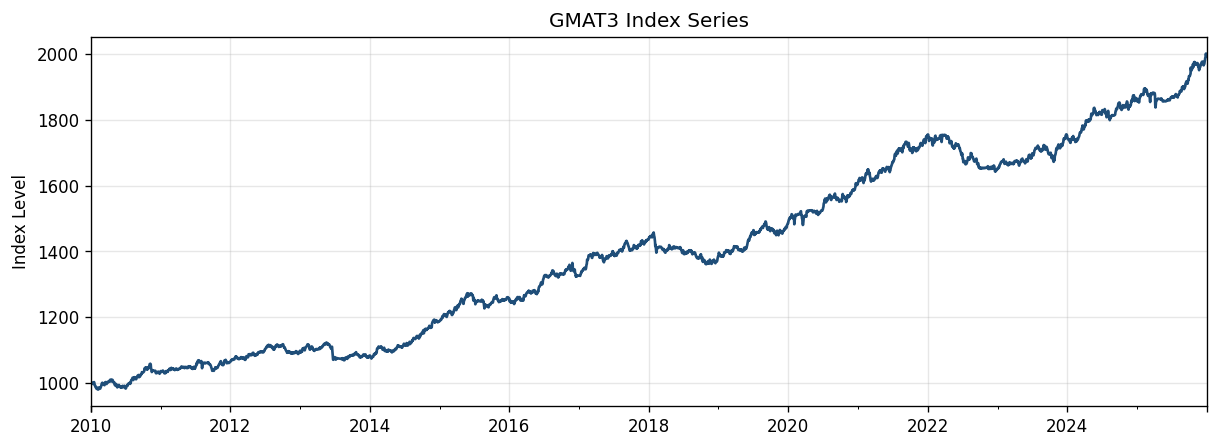

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
result.index_series.plot(ax=ax, lw=1.6, color="#1f4e79")
ax.set_title("GMAT3 Index Series")
ax.set_ylabel("Index Level")
ax.grid(alpha=0.3)
plt.show()

## 6. 可选：对照旧 ddb 结果

如果旧结果文件存在，就直接比较指数终值和最大误差。

In [12]:
legacy_path = ROOT.parent / "ddb" / "results" / "index_series.csv"

if legacy_path.exists():
    legacy = pd.read_csv(legacy_path, index_col=0, parse_dates=True).iloc[:, 0]
    aligned = pd.concat(
        [result.index_series.rename("cta_lab"), legacy.rename("legacy")],
        axis=1,
        join="inner",
    )
    aligned["abs_diff"] = (aligned["cta_lab"] - aligned["legacy"]).abs()
    display(aligned.tail())
    print("max abs diff:", aligned["abs_diff"].max())
else:
    print("legacy index_series.csv not found:", legacy_path)

,cta_lab,legacy,abs_diff
2025-12-25,1989.833785,1989.768547,0.065238
2025-12-26,1999.486704,1999.421150,0.065554
2025-12-29,2000.991686,2000.926082,0.065604
2025-12-30,1993.725609,1993.660243,0.065366
2025-12-31,1991.975916,1991.910608,0.065308


max abs diff: 0.23905690838614646


## 7. 导出正式结果

In [13]:
result.index_series.to_csv(OUTPUT_DIR / "index_series.csv", header=["GMAT3"])
result.value_df.to_csv(OUTPUT_DIR / "sub_portfolio_values.csv")
result.weight_df.to_csv(OUTPUT_DIR / "weights.csv")

schedule_rows = []
for sub_n, item in result.schedule.items():
    for d in item["calc_dates"]:
        schedule_rows.append({"sub_index": sub_n, "type": "calc", "date": d})
    for d in item["adjust_dates"]:
        schedule_rows.append({"sub_index": sub_n, "type": "adjust", "date": d})

schedule_df = pd.DataFrame(schedule_rows).sort_values(["date", "sub_index", "type"])
schedule_df.to_csv(OUTPUT_DIR / "rebalance_schedule.csv", index=False)

print("saved to:", OUTPUT_DIR)
display(schedule_df.tail())

saved to: /home/ubuntu/dengl/my_projects/cta_lab/results/gmat3_strategy_run


,sub_index,type,date
959,3,calc,2025-12-04
767,2,adjust,2025-12-05
1343,4,calc,2025-12-05
1151,3,adjust,2025-12-08
1535,4,adjust,2025-12-09


## 8. 调试建议

- 如果只是验证通路，先把 `SUB_PORTFOLIOS` 设成 `['IF', 'ES', 'AU']`
- 如果要正式复现旧 `ddb`，保持 `SUB_PORTFOLIOS = None`
- 如果想加快重复实验，可以把 `END_DATE` 暂时改短
- 后续若需要，也可以把这份 notebook 改成按 `raw_root` 切换不同数据目录
